# Hypothesis Testing — Practical Notebook

This notebook provides hands-on practice for the hypothesis-testing concepts in the README. It covers hypothesis setup, z-tests, t-tests, proportion tests, p-values, critical values, and interpretation.

## Learning Objectives

- formulate null and alternative hypotheses;
- calculate test statistics;
- calculate p-values;
- make decisions using significance levels;
- perform one-sample z and t tests;
- test a population proportion;
- understand Type I and Type II errors;
- interpret results in context.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

## 1. One-Sample z-Test for a Mean

Example: $\bar{x}=32$, $\mu_0=30$, $\sigma=10$, $n=100$.

In [2]:
xbar = 32
mu0 = 30
sigma = 10
n = 100
alpha = 0.05

se = sigma / np.sqrt(n)
z = (xbar - mu0) / se
p_value = 2 * stats.norm.sf(abs(z))

print('Standard error:', se)
print('z statistic:', z)
print('p-value:', p_value)
print('Decision:', 'Reject H0' if p_value <= alpha else 'Fail to reject H0')

Standard error: 1.0
z statistic: 2.0
p-value: 0.04550026389635839
Decision: Reject H0


## 2. Critical Value Method

For a two-sided test with $\alpha=0.05$, the normal critical values are approximately $\pm1.96$.

In [3]:
critical = stats.norm.ppf(1 - alpha/2)
print('Critical values:', -critical, critical)
print('Reject?', abs(z) > critical)

Critical values: -1.959963984540054 1.959963984540054
Reject? True


## 3. One-Sample t-Test

Example: $\bar{x}=52$, $s=8$, $n=16$, testing $H_0:\mu=50$.

In [4]:
xbar = 52
mu0 = 50
s = 8
n = 16
df = n - 1

se = s / np.sqrt(n)
t_stat = (xbar - mu0) / se
p_value = 2 * stats.t.sf(abs(t_stat), df)

print('Degrees of freedom:', df)
print('Standard error:', se)
print('t statistic:', t_stat)
print('p-value:', p_value)

Degrees of freedom: 15
Standard error: 2.0
t statistic: 1.0
p-value: 0.3331701359154764


## 4. One-Proportion z-Test

Example: $x=140$, $n=200$, testing $H_0:p=0.60$.

In [5]:
x = 140
n = 200
p0 = 0.60
alpha = 0.05

p_hat = x / n
se0 = np.sqrt(p0 * (1-p0) / n)
z = (p_hat - p0) / se0
p_value = 2 * stats.norm.sf(abs(z))

print('Sample proportion:', p_hat)
print('Null standard error:', se0)
print('z statistic:', z)
print('p-value:', p_value)
print('Decision:', 'Reject H0' if p_value <= alpha else 'Fail to reject H0')

Sample proportion: 0.7
Null standard error: 0.034641016151377546
z statistic: 2.886751345948128
p-value: 0.0038924171227786367
Decision: Reject H0


## 5. Right-Tailed Test

For a right-tailed test, the p-value is the probability to the right of the observed test statistic.

In [6]:
z = 2.0
p_right = stats.norm.sf(z)
print('Right-tailed p-value:', p_right)

Right-tailed p-value: 0.022750131948179195


## 6. Left-Tailed Test

For a left-tailed test, the p-value is the probability to the left of the observed test statistic.

In [7]:
z = -2.0
p_left = stats.norm.cdf(z)
print('Left-tailed p-value:', p_left)

Left-tailed p-value: 0.022750131948179195


## 7. Two-Tailed Test

For a two-tailed test, the p-value includes extreme outcomes in both directions.

In [8]:
z = 2.0
p_two = 2 * stats.norm.sf(abs(z))
print('Two-tailed p-value:', p_two)

Two-tailed p-value: 0.04550026389635839


## 8. Visualising the Standard Normal Rejection Region

This example shows the two-sided 5% rejection regions.

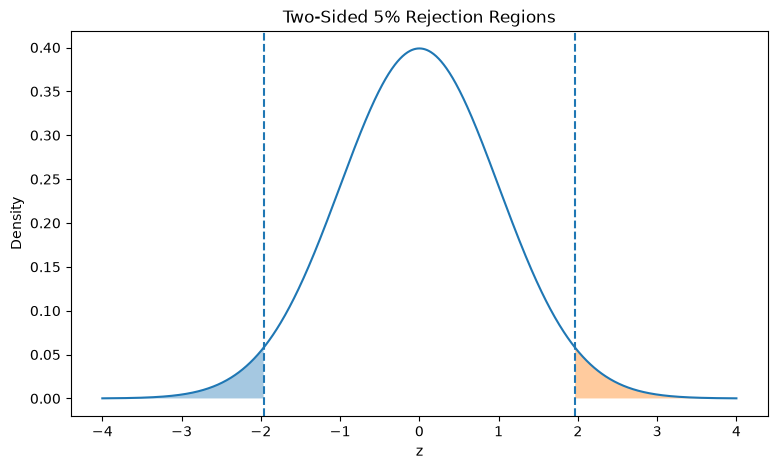

In [9]:
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)
critical = stats.norm.ppf(0.975)

plt.figure(figsize=(9,5))
plt.plot(x, y)
plt.fill_between(x, y, where=(x <= -critical), alpha=0.4)
plt.fill_between(x, y, where=(x >= critical), alpha=0.4)
plt.axvline(-critical, linestyle='--')
plt.axvline(critical, linestyle='--')
plt.xlabel('z')
plt.ylabel('Density')
plt.title('Two-Sided 5% Rejection Regions')
plt.show()

## 9. Type I and Type II Error Concept

Create a simple decision table for review.

In [10]:
table = pd.DataFrame({
    'Reality': ['H0 true', 'H0 true', 'H0 false', 'H0 false'],
    'Decision': ['Reject H0', 'Fail to reject H0', 'Reject H0', 'Fail to reject H0'],
    'Outcome': ['Type I error', 'Correct decision', 'Correct rejection', 'Type II error']
})
table

,Reality,Decision,Outcome
0,H0 true,Reject H0,Type I error
1,H0 true,Fail to reject H0,Correct decision
2,H0 false,Reject H0,Correct rejection
3,H0 false,Fail to reject H0,Type II error


## 10. Paired t-Test

For paired observations, calculate within-pair differences and test whether their mean differs from zero.

In [11]:
before = np.array([70, 72, 68, 75, 71, 69, 74, 73])
after = np.array([73, 74, 70, 78, 73, 72, 76, 76])

difference = after - before
result = stats.ttest_1samp(difference, popmean=0)

print('Mean difference:', difference.mean())
print('t statistic:', result.statistic)
print('p-value:', result.pvalue)

Mean difference: 2.5
t statistic: 13.228756555322954
p-value: 3.2970713382305685e-06


## 11. Practice Questions

1. Write $H_0$ and $H_a$ for the claim that a population mean is greater than 50.
2. Explain the difference between a one-tailed and two-tailed test.
3. Calculate a z statistic for $\bar{x}=32$, $\mu_0=30$, $\sigma=10$, $n=100$.
4. Why is the null value used in the standard error of a one-proportion z-test?
5. Explain Type I and Type II errors.
6. What is statistical power?
7. Why should we say 'fail to reject' rather than 'accept' the null hypothesis?
8. Explain why statistical significance does not automatically imply practical importance.
9. When is a t-test used instead of a z-test for a population mean?
10. Explain why the direction of a one-sided test should be selected before examining the result.

## 12. Final Checklist

Before reporting a hypothesis test, verify the population parameter, hypotheses, tail direction, significance level, test choice, assumptions, test statistic, p-value or critical value, decision, and contextual interpretation.